# PAMA-seq vs 18S sequencing 
#### by Jingjing Cheng and Xiangpeng Li

## Goal
Compare PAMA-seq and 18S-rRNA-seq result 

## PAMA-seq data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_PAMA_rename/`

## 16S data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_18S_rename/`
  
  
## Analysis Folder 
`/data10/xli/project/pama-seq/OL_PAMA_vs_18S_analysis`

In [104]:
!ls /data10/xli/project/pama-seq/OL_18S_analysis/*

/data10/xli/project/pama-seq/OL_18S_analysis/demux-paired.qza
/data10/xli/project/pama-seq/OL_18S_analysis/demux-paired.qzv
/data10/xli/project/pama-seq/OL_18S_analysis/denoising-stats.qza
/data10/xli/project/pama-seq/OL_18S_analysis/manifest.tsv
/data10/xli/project/pama-seq/OL_18S_analysis/Ocean-lake-1a_vs_Ocean-lake-1b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_18S_analysis/Ocean-lake-2a_vs_Ocean-lake-2b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_18S_analysis/Ocean-lake-3a_vs_Ocean-lake-3b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_18S_analysis/Ocean-lake-4a_vs_Ocean-lake-4b_shared_genus.pdf
/data10/xli/project/pama-seq/OL_18S_analysis/qiime2_18s.sh
/data10/xli/project/pama-seq/OL_18S_analysis/rep-seqs.qza
/data10/xli/project/pama-seq/OL_18S_analysis/table.qza
/data10/xli/project/pama-seq/OL_18S_analysis/taxonomy.qza
/data10/xli/project/pama-seq/OL_18S_analysis/taxonomy.qzv

/data10/xli/project/pama-seq/OL_18S_analysis/exported-feature-table:
feature-table.biom  fea

In [105]:
# Import required libraries for data processing, statistics, and visualization

import pandas as pd
import numpy as np
import os

pama_dir =  "/data10/xli/project/pama-seq/OL_PAMA_analysis/"

dir_18s = '/data10/xli/project/pama-seq/OL_18S_analysis/'

path_18s_table = dir_18s + "exported-feature-table/feature_table.tsv"
path_pama_table = pama_dir + "exported-feature-table/feature_table.tsv"

ft18 = pd.read_csv(path_18s_table, sep="\t", skiprows=1).rename(columns=lambda c: c.strip())
ft18 = ft18.rename(columns={ft18.columns[0]: "FeatureID"})

ftp = pd.read_csv(path_pama_table, sep="\t", skiprows=1).rename(columns=lambda c: c.strip())
ftp = ftp.rename(columns={ftp.columns[0]: "FeatureID"})

print("ft16 shape:", ft18.shape, "ftp shape:", ftp.shape)

ft16 shape: (3065, 9) ftp shape: (30970, 9)


In [106]:
ft18.head(2)

,FeatureID,Ocean-lake-1a,Ocean-lake-1b,Ocean-lake-2a,Ocean-lake-2b,Ocean-lake-3a,Ocean-lake-3b,Ocean-lake-4a,Ocean-lake-4b
0,580f28aa5d1f44a43a6dfff991ec40d1,58850.0,59121.0,68237.0,78651.0,116.0,144.0,83.0,117.0
1,00d87d56475b26569d129f896e82aa2a,0.0,0.0,0.0,0.0,19670.0,30384.0,4731.0,6603.0


In [107]:
ftp.head(2)

,FeatureID,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
0,fbe95386d8bf61072772099799630738,82327.0,97900.0,124560.0,120971.0,73.0,139.0,156.0,240.0
1,ac6be611cba1424444b9aa2975c2b7b4,79913.0,95407.0,128280.0,118094.0,80.0,141.0,198.0,162.0


In [108]:
out_dir = '/data10/xli/project/pama-seq/OL_PAMA_vs_18S_analysis/'
os.makedirs(out_dir, exist_ok=True)

In [109]:
# Convert feature tables (18S and PAMA) from wide to long format and remove zero-count entries

long18 = ft18.melt(id_vars="FeatureID", var_name="SampleID", value_name="Count")
long18 = long18[long18["Count"] != 0].copy()

longp = ftp.melt(id_vars="FeatureID", var_name="SampleID", value_name="Count")
longp = longp[longp["Count"] != 0].copy()

print("long18 rows:", long18.shape[0], "longp rows:", longp.shape[0])
long18.head()

long18 rows: 6362 longp rows: 35248


,FeatureID,SampleID,Count
0,580f28aa5d1f44a43a6dfff991ec40d1,Ocean-lake-1a,58850.0
2,b443bc86139d20e266f08bcf24cf751a,Ocean-lake-1a,18097.0
3,4f979d7eedec737a4aaafc26652f6bf2,Ocean-lake-1a,2507.0
4,0f3cd48f1c94814b7154f25164019d34,Ocean-lake-1a,6552.0
5,11b9d90019b1ad2132d54d18269e8cfe,Ocean-lake-1a,59.0


In [110]:
# Load and standardize taxonomy tables (18S and PAMA), ensuring consistent column names and formats

path_18s_tax = dir_18s+ "exported-taxonomy/taxonomy.tsv"
path_pama_tax = pama_dir + "exported-taxonomy/taxonomy.tsv"

tax18 = pd.read_csv(path_18s_tax, sep="\t").rename(columns=lambda c: c.strip())
tax18 = tax18.rename(columns={tax18.columns[0]: "FeatureID"})
tax18["Taxon"] = tax18["Taxon"].astype(str)

taxp = pd.read_csv(path_pama_tax, sep="\t").rename(columns=lambda c: c.strip())
taxp = taxp.rename(columns={taxp.columns[0]: "FeatureID"})
taxp["Taxon"] = taxp["Taxon"].astype(str)

print(tax18.columns)
tax18.head(2)

Index(['FeatureID', 'Taxon', 'Confidence'], dtype='object')


,FeatureID,Taxon,Confidence
0,580f28aa5d1f44a43a6dfff991ec40d1,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Me...,0.966526
1,00d87d56475b26569d129f896e82aa2a,d__Eukaryota,0.998759


<Axes: ylabel='Frequency'>

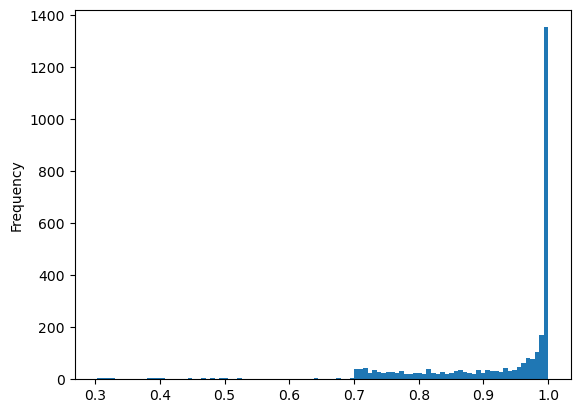

In [111]:
tax18.Confidence.plot.hist(bins=100)

<Axes: ylabel='Frequency'>

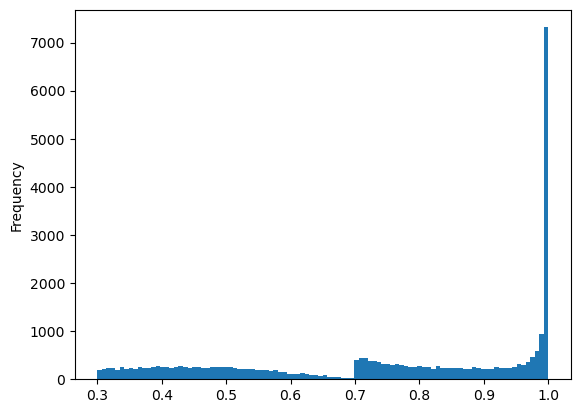

In [112]:
taxp.Confidence.plot.hist(bins=100)

In [113]:
# Filter taxonomy by confidence

conf_thresh = 0.90

tax18_filt = tax18[tax18["Confidence"] >= conf_thresh].copy()
taxp_filt  = taxp[taxp["Confidence"] >= conf_thresh].copy()

print("18S taxonomy:")
print("  before:", tax18.shape)
print("  after :", tax18_filt.shape)

print("PAMA taxonomy:")
print("  before:", taxp.shape)
print("  after :", taxp_filt.shape)

18S taxonomy:
  before: (3065, 3)
  after : (2139, 3)
PAMA taxonomy:
  before: (30970, 3)
  after : (11972, 3)


In [148]:
# Parse taxonomy strings into standardized taxonomic ranks (Kingdom to Species) and handle missing values

levels = ["Kingdom","Phylum","Class","Order","Family","Genus","Species"]

def split_taxon_to_levels(taxon_str: str):
    parts = [p.strip() for p in str(taxon_str).split(";")]
    out = {lv: "Unassigned" for lv in levels}


    for p in parts:
        if p.startswith("d__"): out["Kingdom"] = p.replace("d__", "") or "Unassigned"
        if p.startswith("p__"): out["Phylum"]  = p.replace("p__", "") or "Unassigned"
        if p.startswith("c__"): out["Class"]   = p.replace("c__", "") or "Unassigned"
        if p.startswith("o__"): out["Order"]   = p.replace("o__", "") or "Unassigned"
        if p.startswith("f__"): out["Family"]  = p.replace("f__", "") or "Unassigned"
        if p.startswith("g__"): out["Genus"]   = p.replace("g__", "") or "Unassigned"
        if p.startswith("s__"): out["Species"] = p.replace("s__", "") or "Unassigned"

        if p.startswith("D_0__"): out["Kingdom"] = p.replace("D_0__", "") or "Unassigned"
        if p.startswith("D_1__"): out["Phylum"]  = p.replace("D_1__", "") or "Unassigned"
        if p.startswith("D_2__"): out["Class"]   = p.replace("D_2__", "") or "Unassigned"
        if p.startswith("D_3__"): out["Order"]   = p.replace("D_3__", "") or "Unassigned"
        if p.startswith("D_4__"): out["Family"]  = p.replace("D_4__", "") or "Unassigned"
        if p.startswith("D_5__"): out["Genus"]   = p.replace("D_5__", "") or "Unassigned"
        if p.startswith("D_6__"): out["Species"] = p.replace("D_6__", "") or "Unassigned"


    for lv in levels:
        if out[lv] is None or str(out[lv]).strip()=="":
            out[lv] = "Unassigned"
    return pd.Series(out)

tax18_levels = tax18_filt.join(tax18_filt["Taxon"].apply(split_taxon_to_levels))
taxp_levels  = taxp_filt.join(taxp_filt["Taxon"].apply(split_taxon_to_levels))

taxp_levels[["FeatureID"] + ["Confidence"] + levels].head(5)

,FeatureID,Confidence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,fbe95386d8bf61072772099799630738,0.999910,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned
2,1e69dc1be3d7ebce79c4403528582036,0.992768,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned
3,114ebbae22dde659336c1de48981be71,0.998515,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned
6,814f23eaf5c483399e5a9241f8627296,0.999809,Eukaryota,Arthropoda,Maxillopoda,Unassigned,Unassigned,Unassigned,Unassigned
8,7aca852fc35f7df9dfbbce61860f3594,0.998158,Eukaryota,Xenacoelomorpha,Acoela,Acoela,Acoela,Acoela,Unassigned


In [149]:
# Merge 18S feature abundance with taxonomy annotations and add method/sample identifiers

long18_full = (
    long18
    .merge(tax18_levels[["FeatureID"] + levels], on="FeatureID", how="inner")
)

for lv in levels:
    long18_full[lv] = long18_full[lv].fillna("Unassigned")

long18_full["Method"] = "18S"

long18_full["core"] = long18_full["SampleID"].str.replace("Ocean-lake-", "", regex=False)

print(long18_full.shape)
long18_full.to_csv('/data10/xli/project/pama-seq/OL_dif/18s_long_table.csv')
long18_full.head()

(4488, 12)


,FeatureID,SampleID,Count,Kingdom,Phylum,Class,Order,Family,Genus,Species,Method,core
0,580f28aa5d1f44a43a6dfff991ec40d1,Ocean-lake-1a,58850.0,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,18S,1a
1,0f3cd48f1c94814b7154f25164019d34,Ocean-lake-1a,6552.0,Eukaryota,Chlorophyta,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1a
2,11b9d90019b1ad2132d54d18269e8cfe,Ocean-lake-1a,59.0,Eukaryota,Diatomea,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1a
3,641eb4995a896167800364fac0199771,Ocean-lake-1a,32.0,Eukaryota,Diatomea,Unassigned,Unassigned,Unassigned,Unassigned,Unassigned,18S,1a
4,12a76450d16948a8424ab366731f715d,Ocean-lake-1a,3054.0,Eukaryota,Ciliophora,Intramacronucleata,Spirotrichea,Oligotrichia,Unassigned,Unassigned,18S,1a


In [150]:
# Merge PAMA feature abundance with taxonomy annotations and generate standardized method and sample identifiers

longp_full = (
    longp
    .merge(taxp_levels[["FeatureID"] + levels], on="FeatureID", how="inner")
)

for lv in levels:
    longp_full[lv] = longp_full[lv].fillna("Unassigned")

longp_full["Method"] = "PAMA"
longp_full["core"] = (
    longp_full["SampleID"]
    .str.replace("OL-PAMA-", "", regex=False)
    .str.split("_").str[0]
)

print(longp_full.shape)
longp_full.to_csv('/data10/xli/project/pama-seq/OL_dif/pama_long_table.csv')
longp_full.head()

(13774, 12)


,FeatureID,SampleID,Count,Kingdom,Phylum,Class,Order,Family,Genus,Species,Method,core
0,fbe95386d8bf61072772099799630738,OL-PAMA-1a,82327.0,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned,PAMA,1a
1,114ebbae22dde659336c1de48981be71,OL-PAMA-1a,45570.0,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned,PAMA,1a
2,814f23eaf5c483399e5a9241f8627296,OL-PAMA-1a,2946.0,Eukaryota,Arthropoda,Maxillopoda,Unassigned,Unassigned,Unassigned,Unassigned,PAMA,1a
3,880658c664f0e8e7fc58217cf49ed129,OL-PAMA-1a,9267.0,Eukaryota,Chytridiomycota,Chytridiomycetes,uncultured,uncultured,uncultured,Unassigned,PAMA,1a
4,5816f402bcbb7c62e1ac2a9320b229f9,OL-PAMA-1a,61.0,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned,PAMA,1a


In [151]:
# Concatenate 18S and PAMA datasets into a unified table and standardize column ordering
# Remove entries with unassigned genus to ensure meaningful genus-level comparative analysis

long_all = pd.concat([long18_full, longp_full], ignore_index=True)

cols = ["FeatureID"] + levels + ["SampleID", "Count", "Method", "core"]
long_all = long_all[cols]
long_all = long_all[long_all["Genus"] != "Unassigned"].copy()

print(long_all.shape)
long_all.head()

(10348, 12)


,FeatureID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count,Method,core
0,580f28aa5d1f44a43a6dfff991ec40d1,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,58850.0,18S,1a
7,b0c5b9aafe4462cc72c6e96c60040d26,Eukaryota,Mollusca,Bivalvia,Veneroida,Veneroida,Veneroida,Unassigned,Ocean-lake-1a,2176.0,18S,1a
10,5cf8c03e23441ef96ea64d4f8b542ff3,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,2293.0,18S,1a
12,72baa20d784fde5d3dcb25d911c2e21b,Eukaryota,Ciliophora,Intramacronucleata,Litostomatea,Mesodiniidae,Myrionecta,Unassigned,Ocean-lake-1a,2156.0,18S,1a
21,2fbc153fb7151998bd7a89612af7c275,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,11.0,18S,1a


In [152]:
# Compute total read counts per method (18S and PAMA) across all samples

total_counts_by_method = (
    long_all
    .groupby("Method", as_index=False)["Count"]
    .sum()
    .rename(columns={"Count": "TotalCount"})
)

In [153]:
# Merge total counts back into the main table for normalization or downstream analysis

long_all = long_all.merge(
    total_counts_by_method,
    on="Method",
    how="left"
)

long_all.head()

,FeatureID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count,Method,core,TotalCount
0,580f28aa5d1f44a43a6dfff991ec40d1,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,58850.0,18S,1a,349278.0
1,b0c5b9aafe4462cc72c6e96c60040d26,Eukaryota,Mollusca,Bivalvia,Veneroida,Veneroida,Veneroida,Unassigned,Ocean-lake-1a,2176.0,18S,1a,349278.0
2,5cf8c03e23441ef96ea64d4f8b542ff3,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,2293.0,18S,1a,349278.0
3,72baa20d784fde5d3dcb25d911c2e21b,Eukaryota,Ciliophora,Intramacronucleata,Litostomatea,Mesodiniidae,Myrionecta,Unassigned,Ocean-lake-1a,2156.0,18S,1a,349278.0
4,2fbc153fb7151998bd7a89612af7c275,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Cyclotella,Unassigned,Ocean-lake-1a,11.0,18S,1a,349278.0


In [154]:
long_all.core.unique()

array(['1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b'], dtype=object)

In [155]:
# Calculate relative abundance by normalizing counts within each sample and method

long_all["RelAbundance"] = (
    long_all["Count"]
    / long_all.groupby(["SampleID", "Method"])["Count"].transform("sum")
)

In [156]:
long_all[["SampleID", "Method", "FeatureID", "core", "Genus", "Phylum", "Count", "RelAbundance"]].head()

,SampleID,Method,FeatureID,core,Genus,Phylum,Count,RelAbundance
0,Ocean-lake-1a,18S,580f28aa5d1f44a43a6dfff991ec40d1,1a,Cyclotella,Diatomea,58850.0,0.868212
1,Ocean-lake-1a,18S,b0c5b9aafe4462cc72c6e96c60040d26,1a,Veneroida,Mollusca,2176.0,0.032102
2,Ocean-lake-1a,18S,5cf8c03e23441ef96ea64d4f8b542ff3,1a,Cyclotella,Diatomea,2293.0,0.033829
3,Ocean-lake-1a,18S,72baa20d784fde5d3dcb25d911c2e21b,1a,Myrionecta,Ciliophora,2156.0,0.031807
4,Ocean-lake-1a,18S,2fbc153fb7151998bd7a89612af7c275,1a,Cyclotella,Diatomea,11.0,0.000162


In [157]:
# Standardize SampleID by removing replicate suffix

long_all["SampleID"] = long_all["SampleID"].str.replace(r"_S\d+$", "", regex=True)

In [158]:
# Inspect unique SampleID values to verify naming consistency and replicate structure

long_all["SampleID"].unique()

array(['Ocean-lake-1a', 'Ocean-lake-1b', 'Ocean-lake-2a', 'Ocean-lake-2b',
       'Ocean-lake-3a', 'Ocean-lake-3b', 'Ocean-lake-4a', 'Ocean-lake-4b',
       'OL-PAMA-1a', 'OL-PAMA-1b', 'OL-PAMA-2a', 'OL-PAMA-2b',
       'OL-PAMA-3a', 'OL-PAMA-3b', 'OL-PAMA-4a', 'OL-PAMA-4b'],
      dtype=object)

In [159]:
# Prepare data for genus-level analysis by parsing sample metadata and aggregating relative abundance per replicate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr

df = long_all.copy()

df[["SampleIdx","Rep"]] = df["SampleID"].str.extract(r"-(\d+)([ab])(?:_|$)")
df = df.dropna(subset=["SampleIdx","Rep"])
df["SampleIdx"] = df["SampleIdx"].astype(int)

genus_df = (
    df
    .dropna(subset=["Genus"])
    .groupby(["Method", "SampleIdx", "Rep", "Genus", "Phylum"], as_index=False)["RelAbundance"]
    .sum()
)

In [160]:
# Compute per-sample genus count and total relative abundance (coverage) after filtering

coverage_df = (
    long_all
    .groupby(["Method", "SampleID"])
    .apply(lambda x: pd.Series({
        "n_genus": x["Genus"].notna().sum(),
        "genus_coverage": x.loc[x["Genus"].notna(), "RelAbundance"].sum()
    }))
    .reset_index()
)

/tmp/ipykernel_4092680/718073495.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [161]:
# Count the number of unique genera per sample and method

genus_count_df = (
    long_all
    .dropna(subset=["Genus"])
    .groupby(["Method", "SampleID"])["Genus"]
    .nunique()
    .reset_index(name="n_unique_genus")
)

In [162]:
# Combine coverage and genus count metrics into a single summary table

summary_df = (
    coverage_df
    .merge(genus_count_df, on=["Method", "SampleID"])
)

In [163]:
summary_df

,Method,SampleID,n_genus,genus_coverage,n_unique_genus
0,18S,Ocean-lake-1a,41.0,1.0,31
1,18S,Ocean-lake-1b,38.0,1.0,29
2,18S,Ocean-lake-2a,40.0,1.0,28
3,18S,Ocean-lake-2b,41.0,1.0,29
4,18S,Ocean-lake-3a,78.0,1.0,63
5,18S,Ocean-lake-3b,97.0,1.0,78
6,18S,Ocean-lake-4a,98.0,1.0,78
7,18S,Ocean-lake-4b,117.0,1.0,92
8,PAMA,OL-PAMA-1a,673.0,1.0,251
9,PAMA,OL-PAMA-1b,542.0,1.0,156


In [164]:
# Compute mean genus-level relative abundance across replicates (a/b) for each sample and method

genus_df_mean = (
    genus_df
    .groupby(
        ["Method", "SampleIdx", "Genus", "Phylum"],
        as_index=False
    )["RelAbundance"]
    .mean()
)

In [165]:
# Aggregate genus-level data to ensure one entry per genus per sample, resolving Phylum inconsistencies

genus_unique = (
    genus_df_mean
    .groupby(["Method", "SampleIdx", "Genus"], as_index=False)
    .agg(
        RA=("RelAbundance", "mean"),
        Phylum=("Phylum", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
    )
)

In [166]:
# Split genus-level data by method (18S vs PAMA) and rename columns for comparison

g16 = genus_unique[genus_unique["Method"]=="18S"].rename(
    columns={"RA": "RA_18S", "Phylum": "Phylum_18S"}
)

gp = genus_unique[genus_unique["Method"]=="PAMA"].rename(
    columns={"RA": "RA_PAMA", "Phylum": "Phylum_PAMA"}
)

In [167]:
# Merge 18S and PAMA genus-level abundances, align shared taxa, and handle missing values for comparison

merged_mean = pd.merge(
    g16[["SampleIdx","Genus","Phylum_18S","RA_18S"]],
    gp[["SampleIdx","Genus","Phylum_PAMA","RA_PAMA"]],
    on=["SampleIdx","Genus"],
    how="outer"
)

merged_mean[["RA_18S","RA_PAMA"]] = merged_mean[["RA_18S","RA_PAMA"]].fillna(0)

merged_mean["Phylum_final"] = (
    merged_mean["Phylum_18S"]
    .fillna(merged_mean["Phylum_PAMA"])
    .fillna("Unassigned")
)

In [168]:
merged_mean.groupby(["SampleIdx","Genus"]).size().value_counts()

1    1957
Name: count, dtype: int64

In [169]:
# Compute total and nonzero genus counts per sample for 18S and PAMA, then combine for comparison

g18_cnt = (
    genus_df_mean[genus_df_mean["Method"] == "18S"]
    .groupby("SampleIdx", as_index=False)
    .agg(
        n_genus_total_18S=("Genus", "nunique"),
        n_genus_nonzero_18S=("Genus", lambda g: g[genus_df_mean.loc[g.index, "RelAbundance"] > 0].nunique())
    )
)

gp_cnt = (
    genus_df_mean[genus_df_mean["Method"] == "PAMA"]
    .groupby("SampleIdx", as_index=False)
    .agg(
        n_genus_total_PAMA=("Genus", "nunique"),
        n_genus_nonzero_PAMA=("Genus", lambda g: g[genus_df_mean.loc[g.index, "RelAbundance"] > 0].nunique())
    )
)

genus_counts = (
    g18_cnt.merge(gp_cnt, on="SampleIdx")
    .sort_values("SampleIdx")
)

genus_counts

,SampleIdx,n_genus_total_18S,n_genus_nonzero_18S,n_genus_total_PAMA,n_genus_nonzero_PAMA
0,1,36,36,300,300
1,2,39,39,339,339
2,3,86,86,589,589
3,4,108,108,589,589


In [170]:
# Quantify shared and method-specific genera between 18S and PAMA for each sample

tmp = merged_mean.copy()

tmp["has_18S"]  = tmp["RA_18S"] > 0
tmp["has_PAMA"] = tmp["RA_PAMA"] > 0

g = (
    tmp.groupby(["SampleIdx", "Genus"], as_index=False)
       .agg(has_18S=("has_18S", "any"),
            has_PAMA=("has_PAMA", "any"))
)

g["shared"]    = g["has_18S"] & g["has_PAMA"]
g["only_18S"]  = g["has_18S"] & (~g["has_PAMA"])
g["only_PAMA"] = (~g["has_18S"]) & g["has_PAMA"]

genus_overlap = (
    g.groupby("SampleIdx", as_index=False)[
        ["has_18S", "has_PAMA", "shared", "only_18S", "only_PAMA"]
    ].sum()
    .rename(columns={
        "has_18S": "n_genus_18S",
        "has_PAMA": "n_genus_PAMA",
        "shared": "n_genus_shared",
        "only_18S": "n_genus_18S_only",
        "only_PAMA": "n_genus_PAMA_only",
    })
    .sort_values("SampleIdx")
)

genus_overlap

,SampleIdx,n_genus_18S,n_genus_PAMA,n_genus_shared,n_genus_18S_only,n_genus_PAMA_only
0,1,36,300,16,20,284
1,2,39,339,10,29,329
2,3,86,589,52,34,537
3,4,108,589,51,57,538


In [171]:
# Compute Spearman correlation between 18S and PAMA genus-level abundances for each sample

from scipy.stats import spearmanr

spearman_df = (
    merged_mean
    .groupby("SampleIdx")
    .apply(
        lambda x: spearmanr(
            x["RA_18S"], 
            x["RA_PAMA"]
        )[0]
    )
    .reset_index(name="spearman_rho")
)

spearman_df

/tmp/ipykernel_4092680/315986768.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,SampleIdx,spearman_rho
0,1,-0.210503
1,2,-0.323828
2,3,-0.145511
3,4,-0.205900


In [172]:
# Compute Spearman correlation using only shared genera (nonzero in both 18S and PAMA)

from scipy.stats import spearmanr

spearman_shared_df = (
    merged_mean
    .query("RA_18S > 0 and RA_PAMA > 0")
    .groupby("SampleIdx")
    .apply(lambda x: spearmanr(x["RA_18S"], x["RA_PAMA"])[0])
    .reset_index(name="spearman_rho_shared")
)

spearman_shared_df

/tmp/ipykernel_4092680/2806708248.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: spearmanr(x["RA_18S"], x["RA_PAMA"])[0])


,SampleIdx,spearman_rho_shared
0,1,0.297059
1,2,0.575758
2,3,0.580754
3,4,0.337481


In [173]:
# Identify top phyla by combined abundance and assign colors for visualization

top_n = 20

phyla_weight = (
    merged_mean.assign(weight=merged_mean["RA_18S"] + merged_mean["RA_PAMA"])
    .groupby("Phylum_final")["weight"]
    .sum()
    .sort_values(ascending=False)
)

top_phyla = phyla_weight.index[:top_n].tolist()

merged_mean["Phylum_plot"] = np.where(
    merged_mean["Phylum_final"].isin(top_phyla),
    merged_mean["Phylum_final"],
    "Other"
)

cmap = cm.get_cmap("tab20", top_n)
phylum_to_color = {p: cmap(i) for i, p in enumerate(top_phyla)}
phylum_to_color["Other"] = "#BDBDBD"

/tmp/ipykernel_4092680/2180862370.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", top_n)


In [174]:
# Prepare parameters and inspect data structure before visualization

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pseudo = 1e-6
sample_ids = sorted(merged_mean["SampleIdx"].unique())

print("sample_ids:", sample_ids)
print("merged_mean shape:", merged_mean.shape)
print("columns:", [c for c in ["SampleIdx","Genus","RA_18S","RA_PAMA","Phylum_plot"] if c in merged_mean.columns])

sample_ids: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
merged_mean shape: (1957, 8)
columns: ['SampleIdx', 'Genus', 'RA_18S', 'RA_PAMA', 'Phylum_plot']


In [175]:
# Inspect a single sample to evaluate zero-inflation and data distribution across methods

sid0 = sample_ids[0]
sub0 = merged_mean[merged_mean["SampleIdx"] == sid0]

print("Test sample:", sid0)
print("sub0 shape:", sub0.shape)
print("RA_18S zeros:", (sub0["RA_18S"] == 0).sum(), " / ", len(sub0))
print("RA_PAMA zeros:", (sub0["RA_PAMA"] == 0).sum(), " / ", len(sub0))
sub0.head()

Test sample: 1
sub0 shape: (320, 8)
RA_18S zeros: 284  /  320
RA_PAMA zeros: 20  /  320


,SampleIdx,Genus,Phylum_18S,RA_18S,Phylum_PAMA,RA_PAMA,Phylum_final,Phylum_plot
0,1,0319-6G20,Bdellovibrionota,0.000146,Bdellovibrionota,0.000550,Bdellovibrionota,Other
1,1,37-13,NaN,0.000000,Bacteroidota,0.000363,Bacteroidota,Bacteroidota
2,1,4-29-1,NaN,0.000000,Nitrospirota,0.000348,Nitrospirota,Other
3,1,67-14,NaN,0.000000,Actinobacteriota,0.000421,Actinobacteriota,Actinobacteriota
4,1,A0839,NaN,0.000000,Proteobacteria,0.000294,Proteobacteria,Proteobacteria


In [176]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "DejaVu Sans",  
    "mathtext.fontset": "dejavusans",
    "svg.fonttype": "none",        
    "pdf.fonttype": 42,             
})

Figure/axes created: 4


/tmp/ipykernel_4092680/2980449917.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


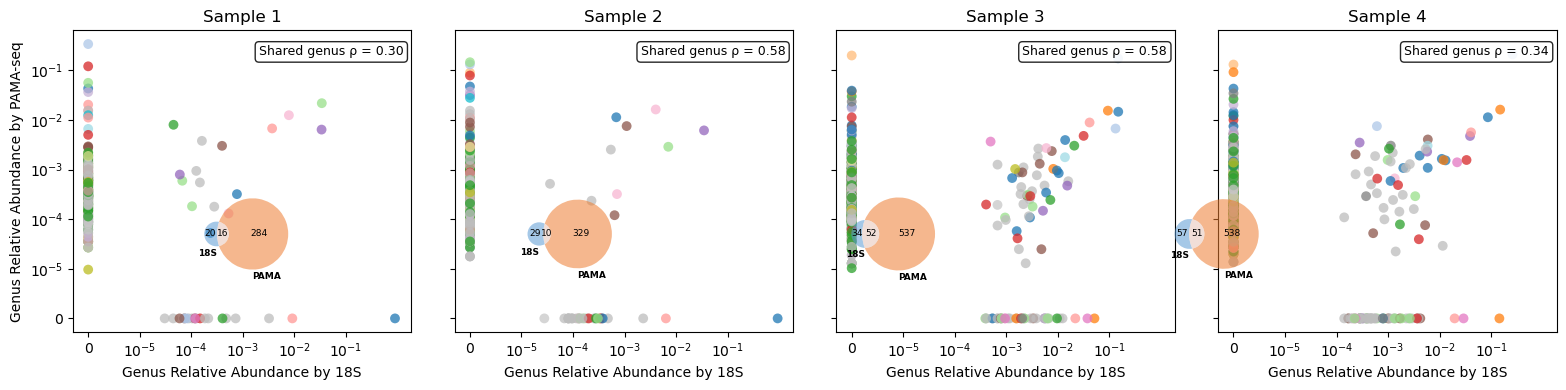

In [177]:
# Generate scatter plots comparing 18S and PAMA genus-level abundances with Venn diagrams showing shared taxa

import matplotlib as mpl
from matplotlib_venn import venn2

mpl.rcParams.update({
    "font.family": "DejaVu Sans",  
    "mathtext.fontset": "dejavusans",
    "svg.fonttype": "none",        
    "pdf.fonttype": 42,          
})

fig, axes = plt.subplots(
    1, len(sample_ids),
    figsize=(4 * len(sample_ids), 4),
    sharex=True,
    sharey=True
)

if len(sample_ids) == 1:
    axes = [axes]

print("Figure/axes created:", len(axes))

for ax, sid in zip(axes, sample_ids):
    sub = merged_mean[merged_mean["SampleIdx"] == sid]
    colors = sub["Phylum_plot"].map(phylum_to_color)

    x = np.log10(sub["RA_18S"] + pseudo)
    y = np.log10(sub["RA_PAMA"] + pseudo)
    ax.scatter(x, y, s=50, c=colors, alpha=0.75, edgecolors="none")
    
    ticks = [-6, -5, -4, -3, -2, -1]
    labels = [
    "0",
    r"$10^{-5}$",
    r"$10^{-4}$",
    r"$10^{-3}$",
    r"$10^{-2}$",
    r"$10^{-1}$",
]

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    mask_all = (sub["RA_18S"] > 0) | (sub["RA_PAMA"] > 0)
    mask_shared = (sub["RA_18S"] > 0) & (sub["RA_PAMA"] > 0)

    rho_all = spearmanr(sub.loc[mask_all, "RA_18S"], sub.loc[mask_all, "RA_PAMA"])[0]
    rho_shared = spearmanr(sub.loc[mask_shared, "RA_18S"], sub.loc[mask_shared, "RA_PAMA"])[0]

    ax.set_title(f"Sample {sid}")
    
    set_18S  = set(sub.loc[sub["RA_18S"]  > 0, "Genus"])
    set_PAMA = set(sub.loc[sub["RA_PAMA"] > 0, "Genus"])

    ax_pos = ax.get_position()
    inset = fig.add_axes([
        ax_pos.x0 + ax_pos.width  * 0.01,   
        ax_pos.y0 + ax_pos.height * 0.2,    
        ax_pos.width  * 0.36,              
        ax_pos.height * 0.36,              
    ])
    v = venn2(
        [set_18S, set_PAMA],
        set_labels=("18S", "PAMA"),
        set_colors=("#5B9BD5", "#ED7D31"),
        alpha=0.55,
        ax=inset
    )
    for text in inset.texts:
        text.set_fontsize(6.5)
    if v.set_labels:
        for lbl in v.set_labels:
            if lbl:
                lbl.set_fontsize(6.5)
                lbl.set_fontweight("bold")
    if v.subset_labels:
        for lbl in v.subset_labels:
            if lbl:
                lbl.set_fontsize(6.5)
    inset.set_facecolor("none")
    
    ax.text(
        0.55, 0.95,
        f"Shared genus ρ = {rho_shared:.2f}",
        transform=ax.transAxes,
        ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_xlabel("Genus Relative Abundance by 18S")
    if ax is axes[0]:
        ax.set_ylabel("Genus Relative Abundance by PAMA-seq")

plt.tight_layout()
plt.savefig(out_dir + "pama_vs_18S.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [178]:
merged_mean.to_csv(out_dir + "pama_vs_18s_table.csv", index=False)

In [179]:
merged_mean

,SampleIdx,Genus,Phylum_18S,RA_18S,Phylum_PAMA,RA_PAMA,Phylum_final,Phylum_plot
0,1,0319-6G20,Bdellovibrionota,0.000146,Bdellovibrionota,0.000550,Bdellovibrionota,Other
1,1,37-13,NaN,0.000000,Bacteroidota,0.000363,Bacteroidota,Bacteroidota
2,1,4-29-1,NaN,0.000000,Nitrospirota,0.000348,Nitrospirota,Other
3,1,67-14,NaN,0.000000,Actinobacteriota,0.000421,Actinobacteriota,Actinobacteriota
4,1,A0839,NaN,0.000000,Proteobacteria,0.000294,Proteobacteria,Proteobacteria
...,...,...,...,...,...,...,...,...
1952,4,mle1-8,NaN,0.000000,Planctomycetota,0.000287,Planctomycetota,Planctomycetota
1953,4,pItb-vmat-80,NaN,0.000000,Proteobacteria,0.000674,Proteobacteria,Proteobacteria
1954,4,possible_genus_03,NaN,0.000000,Fibrobacterota,0.000187,Fibrobacterota,Other
1955,4,uncultured,Bdellovibrionota,0.005359,Actinobacteriota,0.002589,Bdellovibrionota,Other


In [180]:
out_dir

'/data10/xli/project/pama-seq/OL_PAMA_vs_18S_analysis/'